In [3]:
import psycopg2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Conexión a PostgreSQL
conn = psycopg2.connect(
    host='localhost', port=5432,
    database='divisas_db', user='etl_user', password='etl1234'
)

df = pd.read_sql("SELECT * FROM tasas_cambio ORDER BY fecha_extraccion ASC", conn)
conn.close()

df['fecha_extraccion'] = pd.to_datetime(df['fecha_extraccion'])
df['dia'] = (df['fecha_extraccion'] - df['fecha_extraccion'].min()).dt.days

print(f"Total registros: {len(df)}")
print(f"Monedas: {df['moneda_destino'].unique()}")
df.head()

Total registros: 728
Monedas: ['EUR' 'AUD' 'CAD' 'MXN' 'BRL' 'JPY' 'GBP' 'COP']


,id,moneda_base,moneda_destino,tasa_cambio,inversa,fecha_actualizacion_api,fecha_extraccion,dia
0,9,USD,EUR,0.854356,1.170472,simulado,2025-12-11 11:19:17.915282,0
1,16,USD,AUD,1.401874,0.713331,simulado,2025-12-11 11:19:17.915282,0
2,15,USD,CAD,1.351567,0.739882,simulado,2025-12-11 11:19:17.915282,0
3,14,USD,MXN,17.846230,0.056034,simulado,2025-12-11 11:19:17.915282,0
4,13,USD,BRL,5.110051,0.195693,simulado,2025-12-11 11:19:17.915282,0


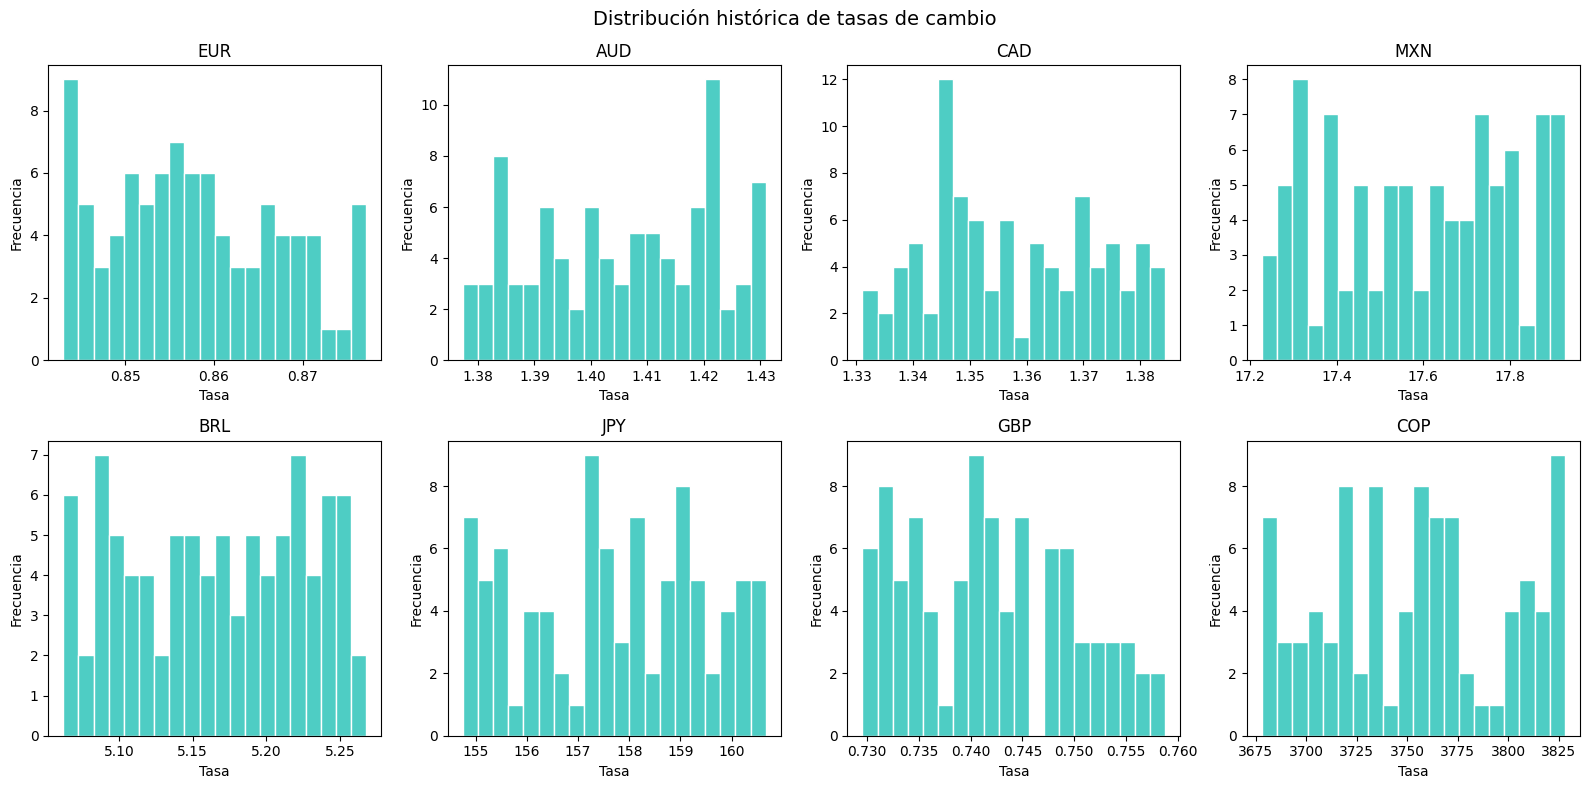


ESTADÍSTICAS DESCRIPTIVAS:
                     mean      std        min        max
moneda_destino                                          
AUD                1.4057   0.0157     1.3773     1.4309
BRL                5.1661   0.0605     5.0622     5.2677
CAD                1.3577   0.0148     1.3311     1.3844
COP             3753.5956  44.9266  3678.0464  3827.9854
EUR                0.8578   0.0096     0.8430     0.8772
GBP                0.7419   0.0080     0.7296     0.7588
JPY              157.7127   1.7624   154.7491   160.6642
MXN               17.5929   0.2123    17.2281    17.9265


In [4]:
# Análisis exploratorio
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribución histórica de tasas de cambio', fontsize=14)

monedas = df['moneda_destino'].unique()
for idx, moneda in enumerate(monedas):
    ax = axes[idx // 4][idx % 4]
    datos = df[df['moneda_destino'] == moneda]['tasa_cambio']
    ax.hist(datos, bins=20, color='#4ecdc4', edgecolor='white')
    ax.set_title(moneda)
    ax.set_xlabel('Tasa')
    ax.set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("\nESTADÍSTICAS DESCRIPTIVAS:")
resumen = df.groupby('moneda_destino')['tasa_cambio'].agg(['mean','std','min','max'])
print(resumen.round(4))

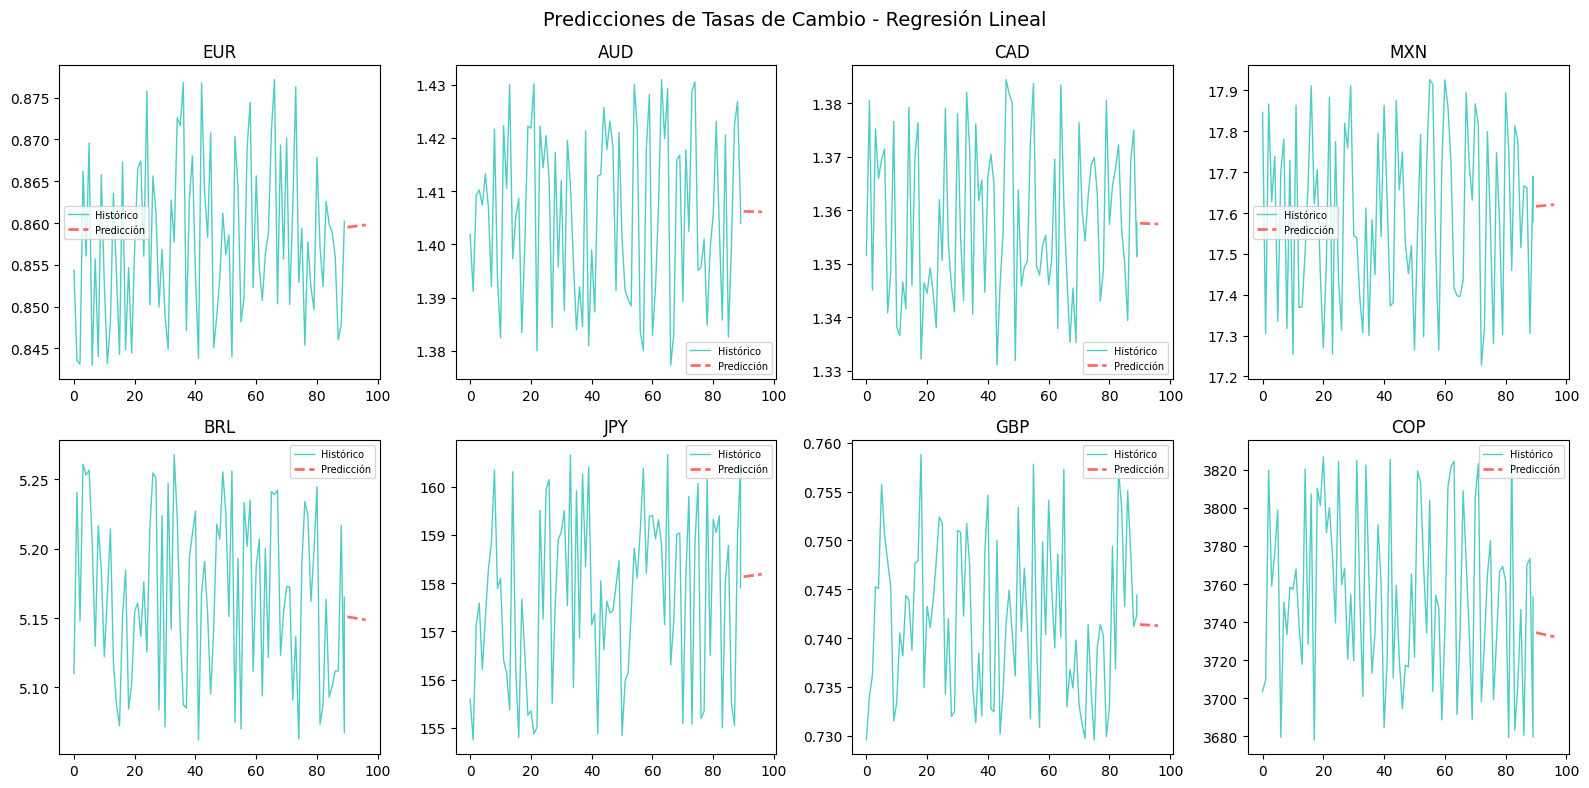


RESULTADOS DEL MODELO:
moneda  tasa_actual  pred_7dias     MAE      R2
   EUR       0.8602      0.8598  0.0070 -0.0072
   AUD       1.4040      1.4061  0.0147 -0.1123
   CAD       1.3577      1.3574  0.0154 -0.0957
   MXN      17.5791     17.6205  0.2172 -0.0422
   BRL       5.1650      5.1487  0.0600 -0.0280
   JPY     157.9017    158.1867  1.3718  0.0598
   GBP       0.7444      0.7413  0.0078 -0.0624
   COP    3753.0880   3732.2750 34.4835 -0.3694


In [6]:
# Modelo ML - Regresión Lineal por moneda
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Predicciones de Tasas de Cambio - Regresión Lineal', fontsize=14)

resultados = []
for idx, moneda in enumerate(monedas):
    datos = df[df['moneda_destino'] == moneda].copy()
    X = datos[['dia']]
    y = datos['tasa_cambio']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    
    y_pred = modelo.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    dias_futuro = np.arange(datos['dia'].max()+1, datos['dia'].max()+8).reshape(-1,1)
    predicciones = modelo.predict(dias_futuro)
    
    resultados.append({
        'moneda': moneda,
        'tasa_actual': round(y.iloc[-1], 4),
        'pred_7dias': round(predicciones[-1], 4),
        'MAE': round(mae, 4),
        'R2': round(r2, 4)
    })
    
    ax = axes[idx // 4][idx % 4]
    ax.plot(datos['dia'], y, color='#4ecdc4', label='Histórico', linewidth=1)
    ax.plot(range(datos['dia'].max()+1, datos['dia'].max()+8), predicciones, 
            color='#ff6b6b', linestyle='--', label='Predicción', linewidth=2)
    ax.set_title(moneda)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Resultados
resultados_df = pd.DataFrame(resultados)
print("\nRESULTADOS DEL MODELO:")
print(resultados_df.to_string(index=False))
